In [1]:

import pandas as pd
import gzip
import json
import matplotlib.pyplot as plt



def parse_first_n(path, n=10000000):
    g = gzip.open( path, 'r')
    for i, l in enumerate(g):
        if i >= n:
            break
        yield json.loads(l)


california_reviews = pd.DataFrame(parse_first_n("data/review-California.json.gz"))
california_metadata = pd.DataFrame(parse_first_n("data/meta-California (1).json.gz"))

In [2]:
category_reference_df = pd.read_csv('data/organized_list.csv')

In [ ]:
# reshape a DataFrame from a wide format to a long format. => Convert the main category column to rows.
reference_long = category_reference_df.melt(
    var_name="main_category",
    value_name="subcategory"
)
reference_long = reference_long.dropna()


In [4]:
# Clean the reference category 
reference_long['subcategory'] = (
    reference_long['subcategory']
    .str.lower()
    .str.strip()
)

## **Normalized Rating**

In [5]:
#Extract all unique category labels from california_metadata

category_df = california_metadata.copy()
category_df = category_df.explode('category')
#Convert everything to lower case and remove blank space 
category_df['category'] = category_df['category'].str.lower().str.strip()


In [6]:
# # # #Remove tiny categories 
category_counts= category_df.get('category').value_counts()
# Setting threshold for the category 
category_counts.describe()
category_counts_threshold = 35 #median

In [7]:
# Map category_count to each category in the df
category_df['category_count'] = category_df['category'].map(category_counts)
category_df = category_df[category_df.get('category_count') > category_counts_threshold]
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,category_count
1,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,"[[Thursday, 6:30AM–6PM], [Friday, 6:30AM–6PM],...","{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,1052.0
2,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...","{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0
3,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...",{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0
4,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,"[[Thursday, 8:30AM–5:30PM], [Friday, 8:30AM–5:...",{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0
5,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,"[[Thursday, 11AM–9:30PM], [Friday, 11AM–9:30PM...","{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,38523.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515957,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,9636.0
515957,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,10208.0
515958,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,297.0
515959,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,532.0


In [8]:
# Calculate mean and standard deviation of each category 
category_stats = category_df.groupby("category")['avg_rating'].agg(['mean', 'std']).reset_index()
category_stats.rename(columns= {'mean': 'category_mean', 'std' : 'category_std'})

,category,category_mean,category_std
0,accountant,4.573494,0.705617
1,accounting firm,4.545570,0.670973
2,acupuncture clinic,4.733915,0.476713
3,acupuncturist,4.772840,0.389780
4,acura dealer,4.358182,0.447500
...,...,...,...
2004,youth center,4.398182,0.477451
2005,youth clothing store,4.374118,0.348518
2006,youth organization,4.327103,0.685609
2007,youth social services organization,4.226667,0.625437


In [9]:
# Merge back into category data set
category_df = category_df.merge(category_stats, on='category', how='left')
category_df = category_df.rename(columns={
    'mean': 'category_mean',
    'std': 'category_std'
})
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,category_count,category_mean,category_std
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,"[[Thursday, 6:30AM–6PM], [Friday, 6:30AM–6PM],...","{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,1052.0,4.277947,0.326921
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...","{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...",{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,"[[Thursday, 8:30AM–5:30PM], [Friday, 8:30AM–5:...",{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022
4,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,"[[Thursday, 11AM–9:30PM], [Friday, 11AM–9:30PM...","{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,38523.0,4.205968,0.422464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,9636.0,4.411571,0.330429
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,10208.0,4.514332,0.285973
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,297.0,4.624242,0.228135
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,532.0,4.438534,0.408986


In [10]:
# Normalized rating
category_df['rating_zscore'] = (
    (category_df['avg_rating'] - category_df['category_mean']) /
    category_df['category_std']
)
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,MISC,state,relative_results,url,category_count,category_mean,category_std,rating_zscore
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,"[[Thursday, 6:30AM–6PM], [Friday, 6:30AM–6PM],...","{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,1052.0,4.277947,0.326921,0.373341
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...","{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-2.829601
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,"[[Thursday, 9AM–5PM], [Friday, 9AM–5PM], [Satu...",{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-0.291672
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,"[[Thursday, 8:30AM–5:30PM], [Friday, 8:30AM–5:...",{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-2.322015
4,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,"[[Thursday, 11AM–9:30PM], [Friday, 11AM–9:30PM...","{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,38523.0,4.205968,0.422464,0.695994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,9636.0,4.411571,0.330429,0.872893
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,"[[Wednesday, 8AM–5PM], [Thursday, 8AM–5PM], [F...",{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,10208.0,4.514332,0.285973,0.649251
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,297.0,4.624242,0.228135,0.770411
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,None,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,532.0,4.438534,0.408986,-0.338725


In [11]:
# Merge with the Reference Table
category_df = category_df.merge(
    reference_long,
    left_on="category",
    right_on="subcategory",
    how="left"
)

In [12]:
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,...,MISC,state,relative_results,url,category_count,category_mean,category_std,rating_zscore,main_category,subcategory
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,...,"{'Service options': ['Takeout', 'Dine-in', 'De...",Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,1052.0,4.277947,0.326921,0.373341,Food & Dining,korean restaurant
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,...,"{'Service options': ['In-store shopping'], 'Pa...",Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-2.829601,Retail & Consumer Services,fabric store
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,...,{'Service options': ['In-store pickup']},Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-0.291672,Retail & Consumer Services,fabric store
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,...,{'Accessibility': ['Wheelchair accessible entr...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-2.322015,Retail & Consumer Services,fabric store
4,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,...,"{'Service options': ['Outdoor seating', 'Curbs...",Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,38523.0,4.205968,0.422464,0.695994,Food & Dining,restaurant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,9636.0,4.411571,0.330429,0.872893,"Arts, Entertainment & Recreation",park
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,10208.0,4.514332,0.285973,0.649251,Hospitality & Tourism,tourist attraction
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,297.0,4.624242,0.228135,0.770411,"Arts, Entertainment & Recreation",state park
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,...,{'Accessibility': ['Wheelchair accessible entr...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,532.0,4.438534,0.408986,-0.338725,Others,play

In [13]:
match_rate = category_df['main_category'].notna().mean() * 100
print(f"Match rate: {match_rate:.2f}%")

Match rate: 99.93%


## **1. How the branding of a business affects reviews?**

In [14]:
####################################################
# Finding a good threshold that consider a brand
####################################################

location_counts = california_metadata.groupby('name')['gmap_id'].nunique()
total_count = california_metadata.get('gmap_id').nunique()

#Calculate proportion for each business
location_proportion = location_counts/total_count

print('Maximum Proportion is:',location_proportion.max())

Maximum Proportion is: 0.005717804705983233


In [15]:
# Create a df that has proportion for each company and filter out brand vs non-brand 
brand_proportion_df = pd.DataFrame()
brand_proportion_df = brand_proportion_df.assign(Proportion = location_proportion)

brand_threshold = location_proportion.quantile(0.95)

brand_proportion_df['is_brand'] = (
    brand_proportion_df['Proportion'] >= brand_threshold
)
# See the count between non-brand vs brand 
brand_proportion_df['is_brand'].value_counts()

is_brand
False    362554
True      23390
Name: count, dtype: int64

In [16]:
brand_proportion_df = brand_proportion_df.reset_index()
brand_proportion_df

,name,Proportion,is_brand
0,"""805"" Auto Details",0.000002,False
1,"""A Heads Up"" Barber Shop",0.000002,False
2,"""Arron Ray Clark Memorial"" Field House",0.000002,False
3,"""Artcentric"" Pottery Painting and Glass Studio",0.000002,False
4,"""BLADE THE BARBER """,0.000002,False
...,...,...,...
385939,🚗 America's Collision Auto Body & Paint,0.000002,False
385940,🚘RG Auto Repairs,0.000002,False
385941,🥇Genesis Window Tint,0.000002,False
385942,🥇Indio Mufflers & Auto Repair,0.000002,False


In [17]:
category_df = category_df.merge(
    brand_proportion_df[['name', 'is_brand']],
    on='name',
    how='left'
)
category_df

,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,...,state,relative_results,url,category_count,category_mean,category_std,rating_zscore,main_category,subcategory,is_brand
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,...,Open ⋅ Closes 6PM,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,1052.0,4.277947,0.326921,0.373341,Food & Dining,korean restaurant,False
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,...,Open ⋅ Closes 5PM,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-2.829601,Retail & Consumer Services,fabric store,False
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,...,Open ⋅ Closes 5PM,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-0.291672,Retail & Consumer Services,fabric store,False
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,...,Open ⋅ Closes 5:30PM,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,536.0,4.414925,0.394022,-2.322015,Retail & Consumer Services,fabric store,False
4,Vons Chicken,"Vons Chicken, 12740 La Mirada Blvd, La Mirada,...",0x80dd2b4c8555edb7:0xfc33d65c4bdbef42,None,33.916402,-118.010855,restaurant,4.5,18,None,...,Open ⋅ Closes 9:30PM,None,https://www.google.com/maps/place//data=!4m2!3...,38523.0,4.205968,0.422464,0.695994,Food & Dining,restaurant,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,9636.0,4.411571,0.330429,0.872893,"Arts, Entertainment & Recreation",park,False
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,...,NaN,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,10208.0,4.514332,0.285973,0.649251,Hospitality & Tourism,tourist attraction,False
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,...,NaN,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,297.0,4.624242,0.228135,0.770411,"Arts, Entertainment & Recreation",state park,False
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,...,NaN,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,532.0,4.438534,0.408986,-0.338725,Others,playground,False


In [14]:
category_df.groupby('is_brand')['rating_zscore'].mean()


is_brand
False    0.128135
True    -0.189321
Name: rating_zscore, dtype: float64

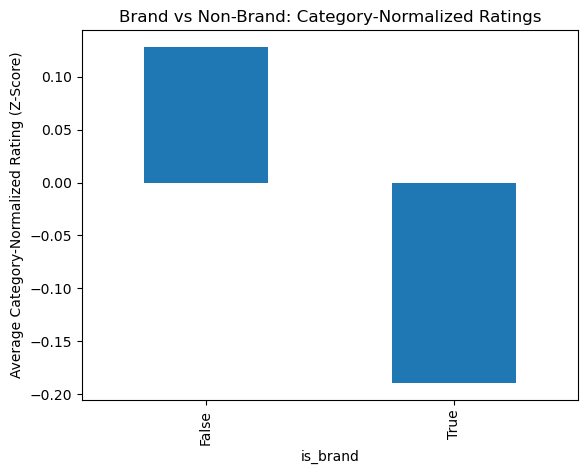

In [15]:

category_df.groupby('is_brand')['rating_zscore'].mean().plot(kind='bar')
plt.ylabel('Average Category-Normalized Rating (Z-Score)')
plt.title('Brand vs Non-Brand: Category-Normalized Ratings')
plt.show()

##### Conclusion: Independent businesses still has higher rate than branded chains.

## **2. In which business categories do independent businesses receive higher customer ratings than branded chains?**

In [18]:
print(california_metadata['category'].iloc[0])
print(type(california_metadata['category'].iloc[0]))

['Textile exporter']
<class 'list'>


In [24]:

print('Highest number of review:',category_df.get('num_of_reviews').max())
print('Total number of category:',category_df.groupby('category').count().shape[0])


Highest number of review: 9998
Total number of category: 2009


In [30]:
# Setting review number to indetify successful businesses
review_num_threshold = 1000
success_business_normalized = category_df[category_df.get('num_of_reviews') > review_num_threshold]

#Compare rating between non-brand and brand in different category
category_brand_ratings_normalize = (
    success_business_normalized
        .groupby(['category_main', 'is_brand'])['rating_zscore']
        .median()
        .unstack()
)

# Keep only category that has both 
comparable_categories_nomalized = category_brand_ratings_normalize.dropna()
comparable_categories_nomalized

is_brand,False,True
category_main,,
Air conditioning contractor,0.505537,0.563908
Airline,1.002973,0.551184
Airport,-0.172743,-0.172743
American restaurant,0.487266,0.416832
Amphitheater,-0.472059,0.670901
...,...,...
Vietnamese restaurant,0.742210,0.348458
Visitor center,0.474002,0.299567
Vista point,0.411198,0.495596


In [33]:
#Measure who performs better
comparable_categories_nomalized["compare"] = comparable_categories_nomalized[False] - comparable_categories_nomalized[True]

#Identify categories where independents outperform
independent_win = comparable_categories_nomalized[comparable_categories_nomalized.get('compare') >0].sort_values(by="compare", ascending=False)
independent_win.head(50)

/var/folders/tl/nq7m6l0d7g3_80l5ngq1x0t00000gn/T/ipykernel_44675/1300152487.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparable_categories_nomalized["compare"] = comparable_categories_nomalized[False] - comparable_categories_nomalized[True]


is_brand,False,True,compare
category_main,,,
Tire shop,1.040067,-0.966063,2.006130
Fast food restaurant,0.950156,-0.871497,1.821653
Vegetarian restaurant,0.554539,-1.197660,1.752198
Frozen yogurt shop,1.486354,-0.049536,1.535890
Modern Indian restaurant,1.159357,-0.250833,1.410190
Warehouse club,1.633004,0.317142,1.315862
Takeout Restaurant,0.888530,-0.344207,1.232737
Sightseeing tour agency,-1.140253,-2.271865,1.131612
Motel,-0.475189,-1.536738,1.061549


##### Top 50 categorical which independent outperform brand

## **3. Which categories are saturated with independents but still highly rated?**
##### *“Saturated” means many independent businesses competing in the same category => has a large number of independent businesses*

In [44]:
independent_normalized = category_df[category_df.get('is_brand') == False]


# Identify saturated category 
saturated_normalized = independent_normalized.groupby('category')['name'].count().reset_index(name='count_saturated').sort_values(by='count_saturated', ascending=False).reset_index(drop=True)

print("Highest number of saturated:",saturated_normalized.get('count_saturated').iloc[0])

# # attach count to each row
independent_normalized['count_saturated'] = independent_normalized['category'].map(
    saturated_normalized.set_index('category')['count_saturated']
)

# # flag saturated
saturated_threshold = 5000
independent_normalized['is_saturated'] = independent_normalized['count_saturated'] > saturated_threshold

independent_normalized

Highest number of saturated: 21553


/var/folders/tl/nq7m6l0d7g3_80l5ngq1x0t00000gn/T/ipykernel_44675/3943425694.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  independent_normalized['count_saturated'] = independent_normalized['category'].map(
/var/folders/tl/nq7m6l0d7g3_80l5ngq1x0t00000gn/T/ipykernel_44675/3943425694.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  independent_normalized['is_saturated'] = independent_normalized['count_saturated'] > saturated_threshold


,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,...,relative_results,url,category_main,category_count,category_mean,category_std,rating_zscore,is_brand,count_saturated,is_saturated
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,...,"[0x80c2c78249aba68f:0x35bf16ce61be751d, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Korean restaurant,1052.0,4.277947,0.326921,0.373341,False,849,False
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,...,"[0x80c2c8811477253f:0x23a8a492df1918f7, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-2.829601,False,335,False
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,...,"[0x80c2c62c496083d1:0xdefa11317fe870a1, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-0.291672,False,335,False
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,...,"[0x80c2cf042a5d9561:0xd0024ad6f81f1335, 0x80c2...",https://www.google.com/maps/place//data=!4m2!3...,Fabric store,536.0,4.414925,0.394022,-2.322015,False,335,False
5,Black Tie Ski Rental Delivery of Mammoth,"Black Tie Ski Rental Delivery of Mammoth, 501 ...",0x80960c29f2e3bf29:0x4b291f0d275a5699,None,37.638754,-118.966055,ski rental service,5.0,34,None,...,"[0x80960dcd6ba76731:0x9a6875ced2f9228e, 0x8096...",https://www.google.com/maps/place//data=!4m2!3...,Ski rental service,123.0,4.517073,0.387025,1.247793,False,105,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,...,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,9636.0,4.411571,0.330429,0.872893,False,7857,True
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,...,"[0x80dcb21eefbd19f5:0x8ebb31f8a91dc2d3, 0x80dc...",https://www.google.com/maps/place//data=!4m2!3...,Park,10208.0,4.514332,0.285973,0.649251,False,8969,True
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,...,"[0x80dcb09dfb76baef:0x5156f914ebbbe, 0x80dcb1e...",https://www.google.com/maps/place//data=!4m2!3...,State park,297.0,4.624242,0.228135,0.770411,False,257,False
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,...,"[0x80dd31044c86de89:0xea5a9038c8f9e2eb, 0x80dd...",https://www.google.com/maps/place//data=!4m2!3...,Playground,532.0,4.438534,0.408986,-0.338725,False,448,False


### **3-case framework**
#### **a. Saturated and poorly rated → Bad market**

In [45]:
# Compute median rating per category (Series)
median_rating_by_category = (
    independent_normalized.groupby('category')['rating_zscore'].median()
)
median_rating_by_category

#how to filter actual businesses ex: park,..

category
accountant                            0.604444
accounting firm                       0.528234
acupuncture clinic                    0.558167
acupuncturist                         0.326236
acura dealer                          0.316912
                                        ...   
youth center                          0.213254
youth clothing store                  0.361193
youth organization                    0.252180
youth social services organization    0.277140
zoo                                   0.254684
Name: rating_zscore, Length: 2009, dtype: float64

In [57]:
# Map back to independent 
independent_normalized['median_rating_z'] = (
    independent_normalized['category'].map(median_rating_by_category)
)
independent_normalized

/var/folders/tl/nq7m6l0d7g3_80l5ngq1x0t00000gn/T/ipykernel_44675/2865879180.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  independent_normalized['median_rating_z'] = (


,name,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,...,category_main,category_count,category_mean,category_std,rating_zscore,is_brand,count_saturated,is_saturated,median_rating,median_rating_z
0,San Soo Dang,"San Soo Dang, 761 S Vermont Ave, Los Angeles, ...",0x80c2c778e3b73d33:0xbdc58662a4a97d49,None,34.058092,-118.292130,korean restaurant,4.4,18,None,...,Korean restaurant,1052.0,4.277947,0.326921,0.373341,False,849,False,0.067457,0.067457
1,Nova Fabrics,"Nova Fabrics, 2200 E 11th St, Los Angeles, CA ...",0x80c2c89923b27a41:0x32041559418d447,None,34.023669,-118.232930,fabric store,3.3,6,None,...,Fabric store,536.0,4.414925,0.394022,-2.829601,False,335,False,0.215913,0.215913
2,Nobel Textile Co,"Nobel Textile Co, 719 E 9th St, Los Angeles, C...",0x80c2c632f933b073:0xc31785961fe826a6,None,34.036694,-118.249421,fabric store,4.3,7,None,...,Fabric store,536.0,4.414925,0.394022,-0.291672,False,335,False,0.215913,0.215913
3,Matrix International Textiles,"Matrix International Textiles, 1363 S Bonnie B...",0x80c2cf163db6bc89:0x219484e2edbcfa41,None,34.015505,-118.181839,fabric store,3.5,6,None,...,Fabric store,536.0,4.414925,0.394022,-2.322015,False,335,False,0.215913,0.215913
5,Black Tie Ski Rental Delivery of Mammoth,"Black Tie Ski Rental Delivery of Mammoth, 501 ...",0x80960c29f2e3bf29:0x4b291f0d275a5699,None,37.638754,-118.966055,ski rental service,5.0,34,None,...,Ski rental service,123.0,4.517073,0.387025,1.247793,False,105,False,0.214268,0.214268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159198,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,park,4.7,763,None,...,Park,9636.0,4.411571,0.330429,0.872893,False,7857,True,0.267618,0.267618
1159199,California Citrus State Historic Park,"California Citrus State Historic Park, 9400 Du...",0x80dcba7983a059af:0x2a006c069483d3d2,Park dedicated to preserving the history of Ca...,33.898611,-117.425703,tourist attraction,4.7,763,None,...,Park,10208.0,4.514332,0.285973,0.649251,False,8969,True,0.299567,0.299567
1159200,California Citrus,"California Citrus, 1999 Van Buren Boulevard, R...",0x80dcb09e3af6228b:0xa55fc2f742364e02,None,33.898299,-117.428067,state park,4.8,96,None,...,State park,297.0,4.624242,0.228135,0.770411,False,257,False,0.332074,0.332074
1159201,Recreation Park Playground,"Recreation Park Playground, 701-939 Federation...",0x80dd31c81d5f153d:0x501886193d0102e7,None,33.775862,-118.135669,playground,4.3,17,None,...,Playground,532.0,4.438534,0.408986,-0.338725,False,448,False,0.150289,0.150289


In [58]:
independent_normalized.get('rating_zscore').median()

0.33660293494252774

In [ ]:
independent_rating_threshold = 0.34

,name,address,gmap_id,description,latitude,longitude,avg_rating,num_of_reviews,price,hours,...,category_main,category_count,category_mean,category_std,rating_zscore,is_brand,count_saturated,is_saturated,median_rating,median_rating_z
category,,,,,,,,,,,,,,,,,,,,,
bar,6682,6679,6682,4155,6682,6682,6682,6682,4691,6176,...,6682,6682,6682,6682,6682,6682,6682,6682,6682,6682
beauty salon,8002,7975,8002,86,8002,8002,8002,8002,39,6611,...,8002,8002,8002,8002,8002,8002,8002,8002,8002,8002
hair salon,5920,5895,5920,83,5920,5920,5920,5920,40,5294,...,5920,5920,5920,5920,5920,5920,5920,5920,5920,5920
mexican restaurant,7719,7703,7719,2069,7719,7719,7719,7719,4807,7418,...,7719,7719,7719,7719,7719,7719,7719,7719,7719,7719
nail salon,5258,5246,5258,32,5258,5258,5258,5258,13,4823,...,5258,5258,5258,5258,5258,5258,5258,5258,5258,5258
park,7857,7856,7857,2052,7857,7857,7857,7857,3,4705,...,7857,7857,7857,7857,7857,7857,7857,7857,7857,7857
tourist attraction,8969,8959,8969,3264,8969,8969,8969,8969,52,6356,...,8969,8969,8969,8969,8969,8969,8969,8969,8969,8969


In [61]:

bad_market = independent_normalized[(independent_normalized.get('is_saturated') == True) & (independent_normalized.get('median_rating_z') < independent_rating_threshold)]
bad_market.groupby('category').count()

,name,address,gmap_id,description,latitude,longitude,avg_rating,num_of_reviews,price,hours,...,category_main,category_count,category_mean,category_std,rating_zscore,is_brand,count_saturated,is_saturated,median_rating,median_rating_z
category,,,,,,,,,,,,,,,,,,,,,
bar,6682,6679,6682,4155,6682,6682,6682,6682,4691,6176,...,6682,6682,6682,6682,6682,6682,6682,6682,6682,6682
beauty salon,8002,7975,8002,86,8002,8002,8002,8002,39,6611,...,8002,8002,8002,8002,8002,8002,8002,8002,8002,8002
hair salon,5920,5895,5920,83,5920,5920,5920,5920,40,5294,...,5920,5920,5920,5920,5920,5920,5920,5920,5920,5920
mexican restaurant,7719,7703,7719,2069,7719,7719,7719,7719,4807,7418,...,7719,7719,7719,7719,7719,7719,7719,7719,7719,7719
nail salon,5258,5246,5258,32,5258,5258,5258,5258,13,4823,...,5258,5258,5258,5258,5258,5258,5258,5258,5258,5258
park,7857,7856,7857,2052,7857,7857,7857,7857,3,4705,...,7857,7857,7857,7857,7857,7857,7857,7857,7857,7857
tourist attraction,8969,8959,8969,3264,8969,8969,8969,8969,52,6356,...,8969,8969,8969,8969,8969,8969,8969,8969,8969,8969


In [62]:
independent_normalized['is_saturated'].value_counts()

is_saturated
False    603448
True      87864
Name: count, dtype: int64

#### **b. Saturated and highly rated → Competitive but viable**

In [63]:
competitive_market = independent_normalized[(independent_normalized.get('is_saturated') == True) & (independent_normalized.get('median_rating') >= independent_rating_threshold)]
competitive_market.groupby('category').count()

,name,address,gmap_id,description,latitude,longitude,avg_rating,num_of_reviews,price,hours,...,category_main,category_count,category_mean,category_std,rating_zscore,is_brand,count_saturated,is_saturated,median_rating,median_rating_z
category,,,,,,,,,,,,,,,,,,,,,
auto repair shop,10513,10477,10513,5,10513,10513,10513,10513,15,9602,...,10513,10513,10513,10513,10513,10513,10513,10513,10513,10513
restaurant,21553,21526,21553,10526,21553,21553,21553,21553,12899,20107,...,21553,21553,21553,21553,21553,21553,21553,21553,21553,21553
service establishment,5391,0,5391,32,5391,5391,5391,5391,26,4876,...,5391,5391,5391,5391,5391,5391,5391,5391,5391,5391


#### **c. Unsaturated and highly rated → Opportunity**

In [65]:
opportunity_market = independent_normalized[(independent_normalized.get('is_saturated') == False) & (independent_normalized.get('median_rating') >= independent_rating_threshold)]
opportunity_market.groupby('category').count()

,name,address,gmap_id,description,latitude,longitude,avg_rating,num_of_reviews,price,hours,...,category_main,category_count,category_mean,category_std,rating_zscore,is_brand,count_saturated,is_saturated,median_rating,median_rating_z
category,,,,,,,,,,,,,,,,,,,,,
accountant,330,324,330,1,330,330,330,330,0,266,...,330,330,330,330,330,330,330,330,330,330
accounting firm,70,69,70,0,70,70,70,70,0,67,...,70,70,70,70,70,70,70,70,70,70
acupuncture clinic,493,492,493,6,493,493,493,493,2,430,...,493,493,493,493,493,493,493,493,493,493
advertising agency,343,330,343,3,343,343,343,343,0,276,...,343,343,343,343,343,343,343,343,343,343
aerobics instructor,29,29,29,2,29,29,29,29,0,23,...,29,29,29,29,29,29,29,29,29,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
x-ray lab,169,169,169,0,169,169,169,169,0,167,...,169,169,169,169,169,169,169,169,169,169
yarn store,84,84,84,20,84,84,84,84,1,76,...,84,84,84,84,84,84,84,84,84,84
yoga instructor,48,41,48,6,48,48,48,48,1,43,...,48,48,48,48,48,48,48,48,48,48


In [68]:
category_df.get('address')[0]

'San Soo Dang, 761 S Vermont Ave, Los Angeles, CA 90005'